In [3]:
import joblib, json
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# --- Modelos ---
modelo_xgb = XGBClassifier(enable_categorical=True)
modelo_xgb.load_model("modelo/modelo_xgb.json")
with open("modelo/config_modelo.json", encoding="utf-8") as f:
    config = json.load(f)

modelo_lgb = joblib.load("modelo/modelo_lgbm.pkl")
with open("modelo/config_lgbm.json", encoding="utf-8") as f:
    config_lgb = json.load(f)



In [ ]:
df = pd.read_csv("datos/train.csv")
X = df[config["columnas"]].copy()
for c, cats in config["categorias"].items():
    X[c] = pd.Categorical(X[c], categories=cats)
y = df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y)

In [4]:
def evaluar(nombre, modelo, umbral, X_, y_, conjunto):
    p = modelo.predict_proba(X_)[:, 1]
    pred = (p >= umbral).astype(int)
    return {
        "Modelo": nombre, "Conjunto": conjunto,
        "AUC": roc_auc_score(y_, p),
        "Accuracy": accuracy_score(y_, pred),
        "Precision": precision_score(y_, pred),
        "Recall": recall_score(y_, pred),
        "F1": f1_score(y_, pred),
    }

filas = []
for nombre, modelo, umbral in [("XGBoost", modelo_xgb, config["umbral"]),
                               ("LightGBM", modelo_lgb, config_lgb["umbral"])]:
    filas.append(evaluar(nombre, modelo, umbral, X_train, y_train, "Train"))
    filas.append(evaluar(nombre, modelo, umbral, X_val, y_val, "Validación"))

tabla = pd.DataFrame(filas).set_index(["Modelo", "Conjunto"]).round(4)
print(tabla)

brecha = (tabla.xs("Train", level="Conjunto")["AUC"]
          - tabla.xs("Validación", level="Conjunto")["AUC"])
print("\nBrecha de AUC (train - validación):")
print(brecha.round(4))

                        AUC  Accuracy  Precision  Recall      F1
Modelo   Conjunto                                               
XGBoost  Train       0.9461    0.8946     0.6637  0.8033  0.7269
         Validación  0.9417    0.8901     0.6522  0.7942  0.7162
LightGBM Train       0.9471    0.8957     0.6671  0.8046  0.7294
         Validación  0.9416    0.8903     0.6535  0.7919  0.7161

Brecha de AUC (train - validación):
Modelo
XGBoost     0.0044
LightGBM    0.0055
Name: AUC, dtype: float64


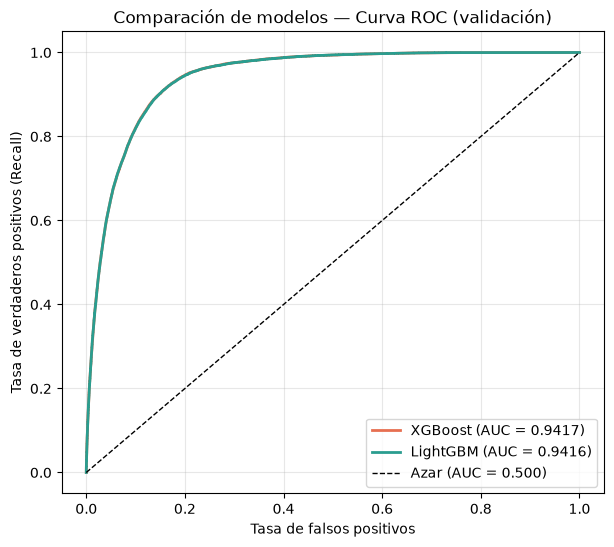

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

proba_xgb = modelo_xgb.predict_proba(X_val)[:, 1]
proba_lgb = modelo_lgb.predict_proba(X_val)[:, 1]

plt.figure(figsize=(7, 6))
for nombre, p, color in [("XGBoost", proba_xgb, '#e76f51'),
                         ("LightGBM", proba_lgb, '#2a9d8f')]:
    fpr, tpr, _ = roc_curve(y_val, p)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{nombre} (AUC = {roc_auc_score(y_val, p):.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Azar (AUC = 0.500)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (Recall)")
plt.title("Comparación de modelos — Curva ROC (validación)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("imagenes/comparacion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

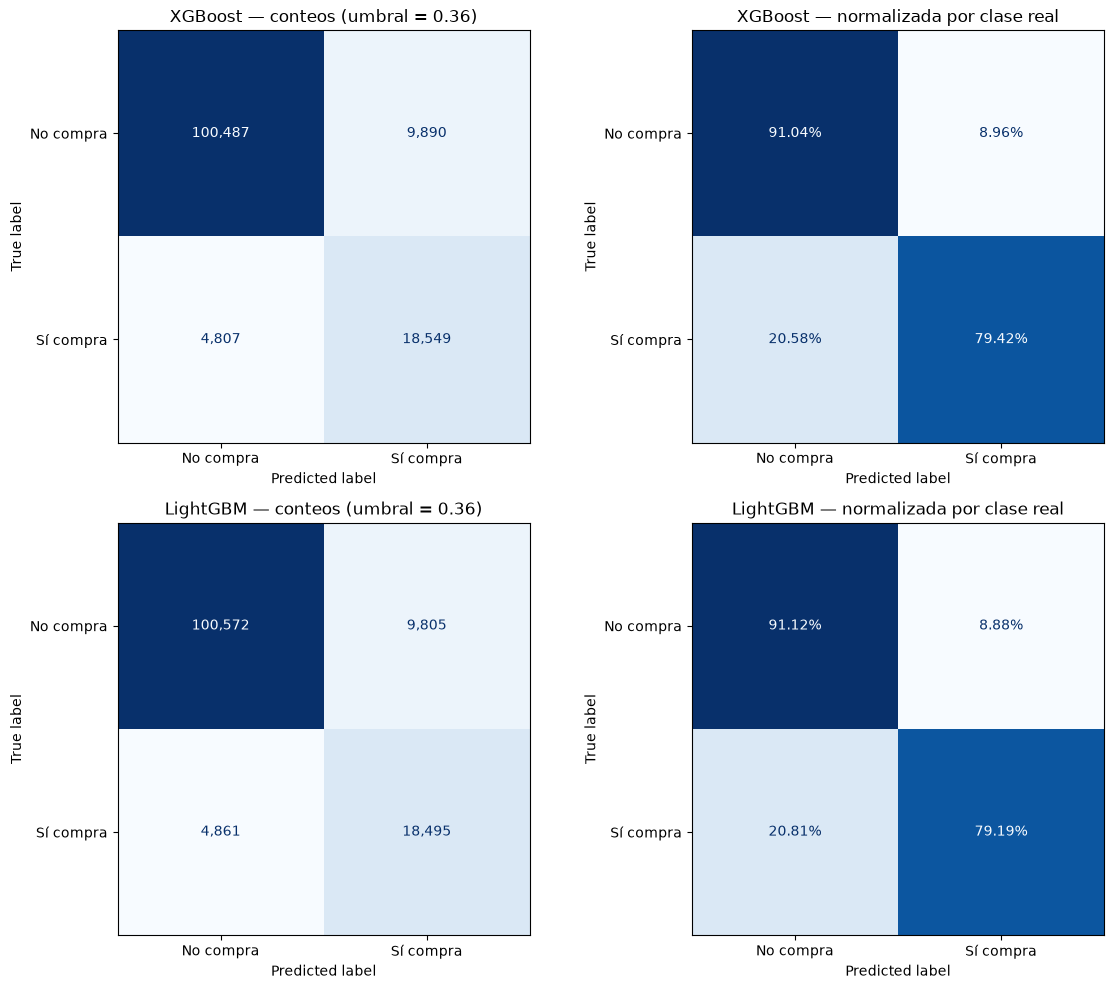

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

etiquetas = ["No compra", "Sí compra"]
modelos = [("XGBoost", proba_xgb, config["umbral"]),
           ("LightGBM", proba_lgb, config_lgb["umbral"])]

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
for i, (nombre, p, u) in enumerate(modelos):
    pred = (p >= u).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_val, pred), display_labels=etiquetas).plot(
        ax=ax[i, 0], cmap="Blues", values_format=",d", colorbar=False)
    ax[i, 0].set_title(f"{nombre} — conteos (umbral = {u:.2f})")

    ConfusionMatrixDisplay(confusion_matrix(y_val, pred, normalize='true'),
                           display_labels=etiquetas).plot(
        ax=ax[i, 1], cmap="Blues", values_format=".2%", colorbar=False)
    ax[i, 1].set_title(f"{nombre} — normalizada por clase real")

plt.tight_layout()
plt.savefig("imagenes/comparacion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()